In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
import os
import matplotlib.pyplot as plt
from collections import OrderedDict
from PIL import Image
import random
import sys
import numpy as np
from sklearn.metrics import confusion_matrix


# ======================= Import dataset utilities ========================
os.chdir("/content/drive/MyDrive/Colab Notebooks/NVDIA_Project/Image-level-micro-gesture-classification")
from dataset import get_train_loader, get_train_dataset

# ======================= Import model utilities ========================
from models.resnet18_model import build_resnet18

In [ ]:
# Connection check to GPU and check if it's available
print(torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
!nvidia-smi

True
Thu Mar 19 19:13:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             16W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+

In [ ]:
# !unzip -q /content/train.zip -d /content/train

In [ ]:
# ------------------ Train and validation data loaders-------------------
# Note: Update the train_dir path to your dataset location
#       If you want to connect to your Google Drive, you can use the first path, but it is slower than the second path which is directly in the Colab environment.
#       You can copy your dataset to the Colab environment for faster access.
#       In our group, we uploaded the dataset as a ZIP file to the Colab environment, then unzipped it and used the second path for training.


# train_dir = "/content/drive/MyDrive/Colab Notebooks/NVDIA_Project/Image-level-micro-gesture-classification/data/train"
train_dir = "/content/train"
batch_size = 64
trainloader, valloader = get_train_loader(train_dir=train_dir, batch_size=batch_size, val_split=0.25, test_split=0.0)

In [ ]:
# Build model
model = build_resnet18()

# Adding pretrained weights to the model
model.load_state_dict(torch.load("outputs/checkpoints/resnet18_micro_gesture.pth"))
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
all_preds = []
all_labels = []

# Test on validation set
with torch.no_grad():
    for inputs, labels in valloader:
        inputs = inputs.to(device)

        outputs = model(inputs)

        # Label with higher probability
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

Validation Accuracy: 45.90%
Total samples: 15128


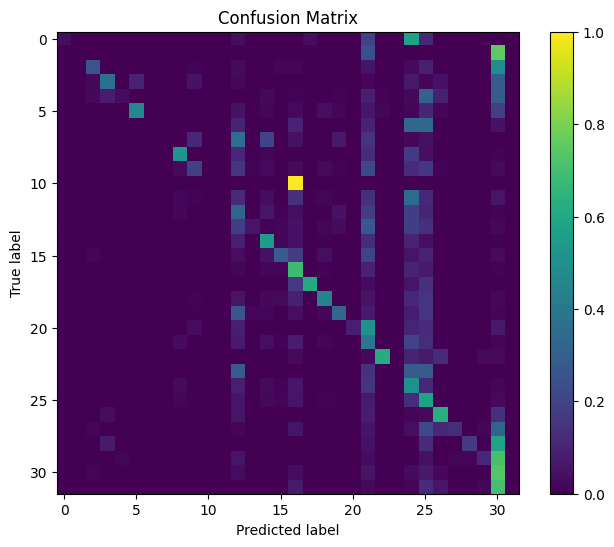

In [ ]:
# Accuracy
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

# Number of samples
print(f"Total samples: {len(all_preds)}")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Convertion in percentages for better visualization
cm_p = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


plt.figure(figsize=(8,6))
plt.imshow(cm_p)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.colorbar()
plt.show()